In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import warnings
warnings.filterwarnings("ignore")

import os
import joblib

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif
)

# Imbalanced Data
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Model Selection
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Explainability
from sklearn.inspection import permutation_importance
import shap


# Train Dataset

In [2]:
train = pd.read_csv("train.csv")
train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [3]:
train.shape

(100000, 28)

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [9]:
# Drop non-predictive identifier columns
train = train.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN', 'Month'])

In [10]:
train.shape

(100000, 23)

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  object 
 1   Occupation                100000 non-null  object 
 2   Annual_Income             100000 non-null  object 
 3   Monthly_Inhand_Salary     84998 non-null   float64
 4   Num_Bank_Accounts         100000 non-null  int64  
 5   Num_Credit_Card           100000 non-null  int64  
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  object 
 8   Type_of_Loan              88592 non-null   object 
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    92998 non-null   object 
 11  Changed_Credit_Limit      100000 non-null  object 
 12  Num_Credit_Inquiries      98035 non-null   float64
 13  Credit_Mix                100000 non-null  ob

In [12]:
#  Clean dirty string values and convert to numeric (float)
numeric_object_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

for col in numeric_object_cols:
    # Remove non-digit chars except dots and minus signs (e.g., '28_' -> '28')
    train[col] = (
        train[col]
        .astype(str)
        .str.replace(r"[^\d.-]", "", regex=True)
    )
    # Convert empty strings or invalid parses to NaN
    train[col] = pd.to_numeric(train[col], errors="coerce")

In [13]:
#  Parse 'Credit_History_Age' into total months
def parse_credit_age(val):
    if pd.isna(val) or not isinstance(val, str):
        return np.nan
    try:
        parts = val.split()
        years = int(parts[0]) if len(parts) > 0 and parts[0].isdigit() else 0
        months = (
            int(parts[3])
            if len(parts) > 3 and parts[3].isdigit()
            else 0
        )
        return years * 12 + months
    except Exception:
        return np.nan


train["Credit_History_Age"] = train["Credit_History_Age"].apply(
    parse_credit_age
)

In [14]:
#  Handle Outliers / Unrealistic Values (Age, Loans, etc.)
train.loc[(train["Age"] < 18) | (train["Age"] > 100), "Age"] = np.nan

# Negative values shouldn't exist in counts or amounts
for col in ["Num_of_Loan", "Num_of_Delayed_Payment", "Outstanding_Debt"]:
    train.loc[train[col] < 0, col] = np.nan

In [15]:
#  Fill Missing Numerical Values (Imputation with Median)
num_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_History_Age",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

for col in num_cols:
    train[col] = train[col].fillna(train[col].median())

print("Data types after conversion:\n", train[num_cols].dtypes)

Data types after conversion:
 Age                        float64
Annual_Income              float64
Monthly_Inhand_Salary      float64
Num_of_Loan                float64
Num_of_Delayed_Payment     float64
Changed_Credit_Limit       float64
Num_Credit_Inquiries       float64
Outstanding_Debt           float64
Credit_History_Age         float64
Amount_invested_monthly    float64
Monthly_Balance            float64
dtype: object


In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  float64
 1   Occupation                100000 non-null  object 
 2   Annual_Income             100000 non-null  float64
 3   Monthly_Inhand_Salary     100000 non-null  float64
 4   Num_Bank_Accounts         100000 non-null  int64  
 5   Num_Credit_Card           100000 non-null  int64  
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  float64
 8   Type_of_Loan              88592 non-null   object 
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    100000 non-null  float64
 11  Changed_Credit_Limit      100000 non-null  float64
 12  Num_Credit_Inquiries      100000 non-null  float64
 13  Credit_Mix                100000 non-null  ob

In [20]:
train.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,34.393360,1.764157e+05,4029.084964,17.091280,22.47443,72.466040,7.002240,21.068780,29.839190,10.368345,27.326780,1426.220376,32.285173,220.997160,1403.118217,614.951381,-3.000000e+22
std,9.685699,1.429618e+06,2961.363540,117.404834,129.05741,466.422621,59.139918,14.860104,218.006683,6.719627,191.293766,1155.129026,5.116875,95.133546,8306.041270,1999.726647,3.162151e+24
min,18.000000,7.005930e+03,303.645417,-1.000000,0.00000,1.000000,0.000000,-5.000000,0.000000,-6.490000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,-3.333333e+26
25%,27.000000,1.945750e+04,1792.084167,3.000000,4.00000,8.000000,2.000000,10.000000,9.000000,5.420000,3.000000,566.072500,28.052567,154.000000,30.306660,77.017414,2.708934e+02
50%,34.000000,3.757861e+04,3093.745000,6.000000,5.00000,13.000000,3.000000,18.000000,14.000000,9.400000,6.000000,1166.155000,32.305784,219.000000,69.249473,135.925682,3.367192e+02
75%,41.000000,7.279092e+04,5371.525000,7.000000,7.00000,20.000000,5.000000,28.000000,18.000000,14.660000,9.000000,1945.962500,36.496663,292.000000,161.224249,255.038698,4.676706e+02
max,100.000000,2.419806e+07,15204.633333,1798.000000,1499.00000,5797.000000,1496.000000,67.000000,4397.000000,36.970000,2597.000000,4998.070000,50.000000,404.000000,82331.000000,10000.000000,1.602041e+03


In [21]:
train.isnull().sum()

Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary           0
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment          0
Changed_Credit_Limit            0
Num_Credit_Inquiries            0
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age              0
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly         0
Payment_Behaviour               0
Monthly_Balance                 0
Credit_Score                    0
dtype: int64

In [26]:
train.shape

(100000, 23)

In [29]:
# Check for unique values.
train.nunique()

Age                             42
Occupation                      16
Annual_Income                13487
Monthly_Inhand_Salary        13235
Num_Bank_Accounts              943
Num_Credit_Card               1179
Interest_Rate                 1750
Num_of_Loan                    413
Type_of_Loan                  6260
Delay_from_due_date             73
Num_of_Delayed_Payment         708
Changed_Credit_Limit          4375
Num_Credit_Inquiries          1223
Credit_Mix                       4
Outstanding_Debt             12203
Credit_Utilization_Ratio    100000
Credit_History_Age             404
Payment_of_Min_Amount            3
Total_EMI_per_month          14950
Amount_invested_monthly      91049
Payment_Behaviour                7
Monthly_Balance              98793
Credit_Score                     3
dtype: int64

In [33]:
print(pd.DataFrame({'Dtype': train.dtypes, 'Non-Null Count': train.notnull().sum(), 'Unique Values': train.nunique()}))

                            Dtype  Non-Null Count  Unique Values
Age                       float64          100000             42
Occupation                 object          100000             16
Annual_Income             float64          100000          13487
Monthly_Inhand_Salary     float64          100000          13235
Num_Bank_Accounts           int64          100000            943
Num_Credit_Card             int64          100000           1179
Interest_Rate               int64          100000           1750
Num_of_Loan               float64          100000            413
Type_of_Loan               object           88592           6260
Delay_from_due_date         int64          100000             73
Num_of_Delayed_Payment    float64          100000            708
Changed_Credit_Limit      float64          100000           4375
Num_Credit_Inquiries      float64          100000           1223
Credit_Mix                 object          100000              4
Outstanding_Debt         

# Test Dataset

In [4]:
test = pd.read_csv("test.csv")
test.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [5]:
test.shape

(50000, 27)

In [22]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

In [23]:
# Drop non-predictive identifier columns
test = test.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN', 'Month'])

In [24]:


# 1. Clean dirty string values and convert to numeric (float)
numeric_object_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

for col in numeric_object_cols:
    test[col] = (
        test[col]
        .astype(str)
        .str.replace(r"[^\d.-]", "", regex=True)
    )
    test[col] = pd.to_numeric(test[col], errors="coerce")

# 2. Parse 'Credit_History_Age' into total months
def parse_credit_age(val):
    if pd.isna(val) or not isinstance(val, str):
        return np.nan
    try:
        parts = val.split()
        years = int(parts[0]) if len(parts) > 0 and parts[0].isdigit() else 0
        months = (
            int(parts[3])
            if len(parts) > 3 and parts[3].isdigit()
            else 0
        )
        return years * 12 + months
    except Exception:
        return np.nan

test["Credit_History_Age"] = test["Credit_History_Age"].apply(parse_credit_age)

# 3. Handle Outliers / Impossible Values
test.loc[(test["Age"] < 18) | (test["Age"] > 100), "Age"] = np.nan

for col in ["Num_of_Loan", "Num_of_Delayed_Payment", "Outstanding_Debt"]:
    test.loc[test[col] < 0, col] = np.nan

# 4. Fill Missing Values using TRAIN SET Medians (No Data Leakage)
num_cols = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_History_Age",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

# Fill missing values in 'test' using 'train' column medians
for col in num_cols:
    train_median = train[col].median()
    test[col] = test[col].fillna(train_median)

print("Test set numerical processing complete. Missing values count:")
print(test[num_cols].isnull().sum())

Test set numerical processing complete. Missing values count:
Age                        0
Annual_Income              0
Monthly_Inhand_Salary      0
Num_of_Loan                0
Num_of_Delayed_Payment     0
Changed_Credit_Limit       0
Num_Credit_Inquiries       0
Outstanding_Debt           0
Credit_History_Age         0
Amount_invested_monthly    0
Monthly_Balance            0
dtype: int64


In [25]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       50000 non-null  float64
 1   Occupation                50000 non-null  object 
 2   Annual_Income             50000 non-null  float64
 3   Monthly_Inhand_Salary     50000 non-null  float64
 4   Num_Bank_Accounts         50000 non-null  int64  
 5   Num_Credit_Card           50000 non-null  int64  
 6   Interest_Rate             50000 non-null  int64  
 7   Num_of_Loan               50000 non-null  float64
 8   Type_of_Loan              44296 non-null  object 
 9   Delay_from_due_date       50000 non-null  int64  
 10  Num_of_Delayed_Payment    50000 non-null  float64
 11  Changed_Credit_Limit      50000 non-null  float64
 12  Num_Credit_Inquiries      50000 non-null  float64
 13  Credit_Mix                50000 non-null  object 
 14  Outsta

In [27]:
test.shape

(50000, 22)

In [28]:
test.isnull().sum()

Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                5704
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly        0
Payment_Behaviour              0
Monthly_Balance                0
dtype: int64

In [35]:
print(pd.DataFrame({'Dtype': train.dtypes, 'Non-Null Count': train.notnull().sum(), 'Unique Values': train.nunique()}))

                            Dtype  Non-Null Count  Unique Values
Age                       float64          100000             42
Occupation                 object          100000             16
Annual_Income             float64          100000          13487
Monthly_Inhand_Salary     float64          100000          13235
Num_Bank_Accounts           int64          100000            943
Num_Credit_Card             int64          100000           1179
Interest_Rate               int64          100000           1750
Num_of_Loan               float64          100000            413
Type_of_Loan               object           88592           6260
Delay_from_due_date         int64          100000             73
Num_of_Delayed_Payment    float64          100000            708
Changed_Credit_Limit      float64          100000           4375
Num_Credit_Inquiries      float64          100000           1223
Credit_Mix                 object          100000              4
Outstanding_Debt         

In [34]:
print(pd.DataFrame({'Dtype': test.dtypes, 'Non-Null Count': test.notnull().sum(), 'Unique Values': test.nunique()}))

                            Dtype  Non-Null Count  Unique Values
Age                       float64           50000             40
Occupation                 object           50000             16
Annual_Income             float64           50000          12989
Monthly_Inhand_Salary     float64           50000          12793
Num_Bank_Accounts           int64           50000            540
Num_Credit_Card             int64           50000            819
Interest_Rate               int64           50000            945
Num_of_Loan               float64           50000            251
Type_of_Loan               object           44296           6260
Delay_from_due_date         int64           50000             73
Num_of_Delayed_Payment    float64           50000            408
Changed_Credit_Limit      float64           50000           3920
Num_Credit_Inquiries      float64           50000            750
Credit_Mix                 object           50000              4
Outstanding_Debt         

In [36]:
train["Type_of_Loan"] = train["Type_of_Loan"].fillna("Unknown")
test["Type_of_Loan"] = test["Type_of_Loan"].fillna("Unknown")

In [37]:
train.isnull().sum()

Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

In [38]:
test.isnull().sum()

Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64

# Separate Features and Target

In [39]:
x_train = train.drop("Credit_Score", axis=1)
y_train = train["Credit_Score"]
x_test = test.copy()

In [40]:
print(f"x_train: {x_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"x_test : {x_test.shape}")

x_train: (100000, 22)
y_train: (100000,)
x_test : (50000, 22)


# Encoding

In [41]:
# Find categorical columns
categorical_cols = x_train.select_dtypes(include=["object"]).columns
print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object')


In [42]:
# Create a dictionary to store encoders
label_encoders = {}

In [43]:
# Encode each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col].astype(str))
    label_encoders[col] = le

print("\nEncoding completed!")
print(x_train.head())


Encoding completed!
    Age  Occupation  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  \
0  23.0          12       19114.12            1824.843333                  3   
1  23.0          12       19114.12            3093.745000                  3   
2  34.0          12       19114.12            3093.745000                  3   
3  23.0          12       19114.12            3093.745000                  3   
4  23.0          12       19114.12            1824.843333                  3   

   Num_Credit_Card  Interest_Rate  Num_of_Loan  Type_of_Loan  \
0                4              3          4.0           128   
1                4              3          4.0           128   
2                4              3          4.0           128   
3                4              3          4.0           128   
4                4              3          4.0           128   

   Delay_from_due_date  ...  Num_Credit_Inquiries  Credit_Mix  \
0                    3  ...                   4.

In [44]:
x_train.dtypes

Age                         float64
Occupation                    int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                 float64
Type_of_Loan                  int64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                    int64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount         int64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour             int64
Monthly_Balance             float64
dtype: object

In [45]:
for col in categorical_cols:
    x_test[col] = label_encoders[col].transform(x_test[col].astype(str))

In [46]:
x_test.dtypes

Age                         float64
Occupation                    int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                 float64
Type_of_Loan                  int64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                    int64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount         int64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour             int64
Monthly_Balance             float64
dtype: object

In [48]:
y_train.value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

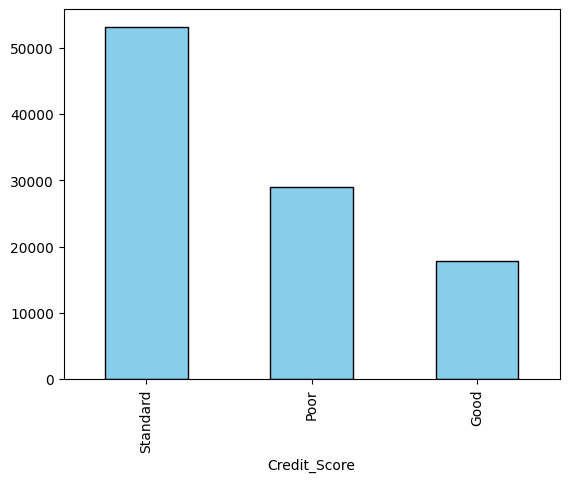

In [49]:
y_train.value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.show()

# Random Forest before Sampling

In [59]:
# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [60]:
# Train the model
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [61]:
rf_model.score(x_train, y_train)

1.0

In [63]:
# Predict on test data
predictions_rf = rf_model.predict(x_test)
predictions_rf

array(['Good', 'Good', 'Good', ..., 'Poor', 'Poor', 'Poor'],
      shape=(50000,), dtype=object)

In [64]:
y_train_pred = rf_model.predict(x_train)

In [65]:

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nClassification Report:\n")
print(classification_report(y_train, y_train_pred))


Training Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

        Good       1.00      1.00      1.00     17828
        Poor       1.00      1.00      1.00     28998
    Standard       1.00      1.00      1.00     53174

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



In [66]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_train, y_train_pred))


Confusion Matrix:

[[17828     0     0]
 [    0 28998     0]
 [    0     0 53174]]


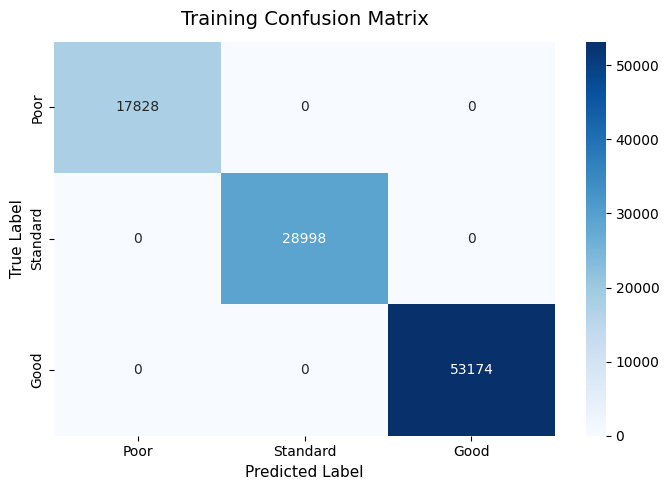

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

# 2. Class labels (mapped to 0: Poor, 1: Standard, 2: Good)
labels = ["Poor", "Standard", "Good"]

# 3. Plot heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
)

plt.title("Training Confusion Matrix", fontsize=14, pad=12)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.show()

# train_test_split

In [110]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# RandomForestClassifier

In [69]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [70]:
train_accuracy = rf_model.score(x_train, y_train)
val_accuracy = rf_model.score(x_val, y_val)

print(f"Training Accuracy : {train_accuracy*100:.2f}%")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

Training Accuracy : 100.00%
Validation Accuracy: 79.22%


In [71]:
predictions = rf_model.predict(x_val)

In [72]:

accuracy_rf = accuracy_score(y_val, predictions)
precision_rf = precision_score(y_val, predictions, average='macro')
recall_rf = recall_score(y_val, predictions, average='macro')
f1_rf = f1_score(y_val, predictions, average='macro')

print(f"Accuracy : {accuracy_rf*100:.2f}%")
print(f"Precision: {precision_rf*100:.2f}%")
print(f"Recall   : {recall_rf*100:.2f}%")
print(f"F1-Score : {f1_rf*100:.2f}%")

Accuracy : 79.22%
Precision: 78.03%
Recall   : 77.92%
F1-Score : 77.97%


In [73]:
print(classification_report(y_val, predictions))

              precision    recall  f1-score   support

        Good       0.75      0.73      0.74      3566
        Poor       0.78      0.80      0.79      5799
    Standard       0.81      0.81      0.81     10635

    accuracy                           0.79     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.79      0.79      0.79     20000



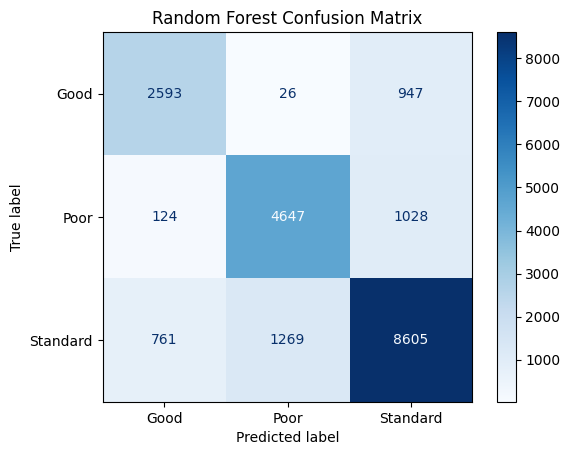

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_val, predictions, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

# Randomized Search

In [75]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 250 ],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt"],
    
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV Score: 0.7519806521919327


In [79]:

# Get the best model
rf_model = random_search.best_estimator_

In [80]:
# Evaluate the tuned model
train_accuracy = rf_model.score(x_train, y_train)
val_accuracy = rf_model.score(x_val, y_val)

print(f"Training Accuracy : {train_accuracy*100:.2f}%")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

Training Accuracy : 92.00%
Validation Accuracy: 77.87%


In [81]:
predictions = rf_model.predict(x_val)

In [82]:
accuracy_rf = accuracy_score(y_val, predictions)
precision_rf = precision_score(y_val, predictions, average='macro')
recall_rf = recall_score(y_val, predictions, average='macro')
f1_rf = f1_score(y_val, predictions, average='macro')

print(f"Accuracy : {accuracy_rf*100:.2f}%")
print(f"Precision: {precision_rf*100:.2f}%")
print(f"Recall   : {recall_rf*100:.2f}%")
print(f"F1-Score : {f1_rf*100:.2f}%")

Accuracy : 77.87%
Precision: 76.19%
Recall   : 76.54%
F1-Score : 76.36%


In [83]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classification Report
print("\nClassification Report")
print(classification_report(y_val, predictions))


Classification Report
              precision    recall  f1-score   support

        Good       0.70      0.72      0.71      3566
        Poor       0.78      0.77      0.78      5799
    Standard       0.81      0.80      0.80     10635

    accuracy                           0.78     20000
   macro avg       0.76      0.77      0.76     20000
weighted avg       0.78      0.78      0.78     20000



In [84]:
# Confusion Matrix
cm = confusion_matrix(y_val, predictions)

print("\nConfusion Matrix")
print(cm)


Confusion Matrix
[[2577   32  957]
 [ 223 4480 1096]
 [ 869 1249 8517]]


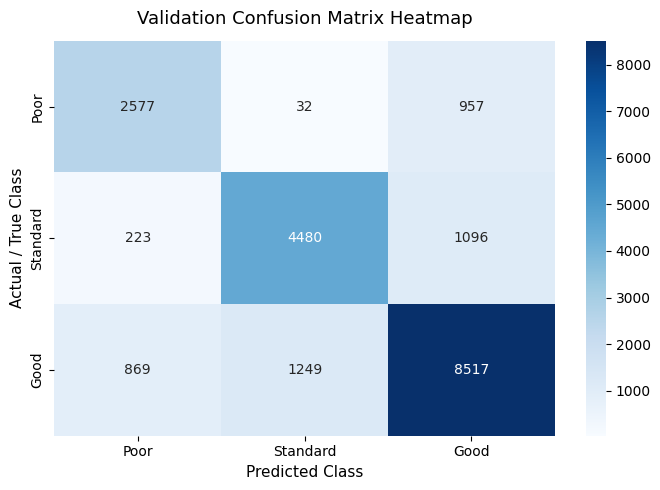

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define class labels matching your mapping (0: Poor, 1: Standard, 2: Good)
labels = ["Poor", "Standard", "Good"]

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
)

plt.title("Validation Confusion Matrix Heatmap", fontsize=13, pad=12)
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("Actual / True Class", fontsize=11)
plt.tight_layout()
plt.show()

# Save the trained Random Forest model


In [87]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, "random_forest_model.joblib")

print("✅ Random Forest model saved successfully!")

✅ Random Forest model saved successfully!


# CatBoost Classifier

In [99]:
cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=10,
    l2_leaf_reg=5,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_seed=42,
    early_stopping_rounds=200,
    verbose=100
)

cat_model.fit(
    x_train,
    y_train,
    eval_set=(x_val, y_val)
)

0:	learn: 0.6783969	test: 0.6706417	best: 0.6706417 (0)	total: 241ms	remaining: 8m 2s
100:	learn: 0.7277497	test: 0.7103205	best: 0.7103710 (99)	total: 20.7s	remaining: 6m 29s
200:	learn: 0.7558624	test: 0.7220934	best: 0.7222593 (197)	total: 40.5s	remaining: 6m 2s
300:	learn: 0.7829638	test: 0.7367691	best: 0.7368974 (296)	total: 1m	remaining: 5m 38s
400:	learn: 0.8049088	test: 0.7509368	best: 0.7509368 (400)	total: 1m 20s	remaining: 5m 19s
500:	learn: 0.8228226	test: 0.7591070	best: 0.7591070 (500)	total: 1m 40s	remaining: 4m 59s
600:	learn: 0.8366060	test: 0.7643624	best: 0.7647978 (598)	total: 1m 59s	remaining: 4m 38s
700:	learn: 0.8473694	test: 0.7694700	best: 0.7695937 (693)	total: 2m 19s	remaining: 4m 17s
800:	learn: 0.8571643	test: 0.7709500	best: 0.7712443 (798)	total: 2m 39s	remaining: 3m 59s
900:	learn: 0.8673533	test: 0.7742602	best: 0.7743097 (891)	total: 3m	remaining: 3m 40s
1000:	learn: 0.8753949	test: 0.7762644	best: 0.7763664 (989)	total: 3m 22s	remaining: 3m 22s
1100:

CatBoostClassifier(depth=10, early_stopping_rounds=200, eval_metric='TotalF1', iterations=2000, l2_leaf_reg=5, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [100]:
train_accuracy = cat_model.score(x_train, y_train)
val_accuracy = cat_model.score(x_val, y_val)

print(f"Training Accuracy : {train_accuracy*100:.2f}%")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

Training Accuracy : 93.61%
Validation Accuracy: 78.87%


In [101]:
predictions = cat_model.predict(x_val)

# Convert predictions to 1D array
predictions = predictions.flatten()

In [102]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_cat = accuracy_score(y_val, predictions)
precision_cat = precision_score(y_val, predictions, average='macro')
recall_cat = recall_score(y_val, predictions, average='macro')
f1_cat = f1_score(y_val, predictions, average='macro')

print(f"Accuracy : {accuracy_cat*100:.2f}%")
print(f"Precision: {precision_cat*100:.2f}%")
print(f"Recall   : {recall_cat*100:.2f}%")
print(f"F1-Score : {f1_cat*100:.2f}%")

Accuracy : 78.87%
Precision: 77.98%
Recall   : 77.28%
F1-Score : 77.62%


In [103]:

print(classification_report(y_val, predictions))

              precision    recall  f1-score   support

        Good       0.75      0.72      0.74      3566
        Poor       0.79      0.78      0.78      5799
    Standard       0.80      0.81      0.81     10635

    accuracy                           0.79     20000
   macro avg       0.78      0.77      0.78     20000
weighted avg       0.79      0.79      0.79     20000



In [104]:
# Confusion Matrix
cm = confusion_matrix(y_val, predictions)

print("\nConfusion Matrix")
print(cm)


Confusion Matrix
[[2568   19  979]
 [  96 4545 1158]
 [ 750 1224 8661]]


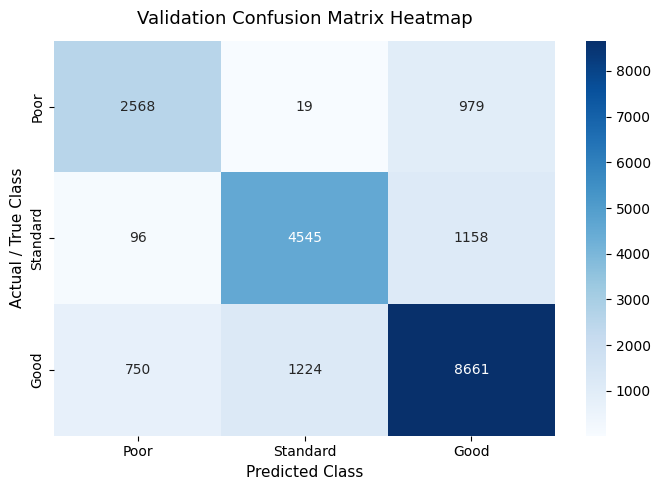

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define class labels matching your mapping (0: Poor, 1: Standard, 2: Good)
labels = ["Poor", "Standard", "Good"]

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
)

plt.title("Validation Confusion Matrix Heatmap", fontsize=13, pad=12)
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("Actual / True Class", fontsize=11)
plt.tight_layout()
plt.show()

In [106]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

                     Feature  Importance
14          Outstanding_Debt    8.319407
8               Type_of_Loan    7.138637
11      Changed_Credit_Limit    6.558881
6              Interest_Rate    6.494867
9        Delay_from_due_date    6.485797
0                        Age    6.439763
1                 Occupation    5.512885
16        Credit_History_Age    5.485290
5            Num_Credit_Card    5.212152
18       Total_EMI_per_month    4.894358
4          Num_Bank_Accounts    4.272419
13                Credit_Mix    4.213608
12      Num_Credit_Inquiries    4.193806
10    Num_of_Delayed_Payment    3.751340
2              Annual_Income    3.679904
15  Credit_Utilization_Ratio    3.116976
21           Monthly_Balance    2.959749
3      Monthly_Inhand_Salary    2.751059
19   Amount_invested_monthly    2.649316
20         Payment_Behaviour    2.617750


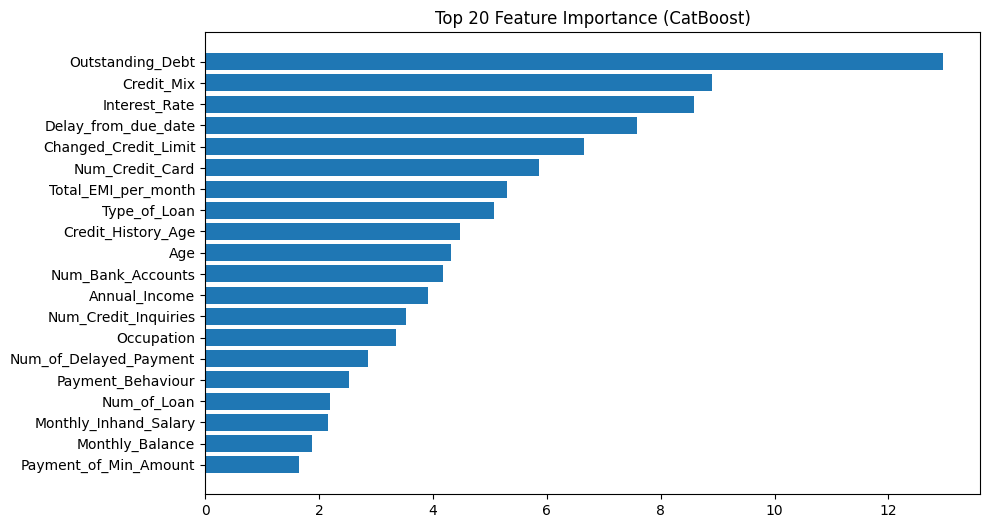

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance["Feature"][:20],
    feature_importance["Importance"][:20]
)
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance (CatBoost)")
plt.show()

In [107]:
import joblib

joblib.dump(cat_model, "catboost_model.joblib")

print("✅ CatBoost model saved successfully!")

✅ CatBoost model saved successfully!


# preprocess for XGBoost

In [116]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Encode target labels
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)

# XGBoost Classifier

In [117]:
# Build XGBoost model
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

# Train the model
xgb_model.fit(
    x_train,
    y_train,
    eval_set=[(x_val, y_val)],
    verbose=100
)

[0]	validation_0-mlogloss:0.98827
[100]	validation_0-mlogloss:0.66945
[200]	validation_0-mlogloss:0.64581
[300]	validation_0-mlogloss:0.63450
[400]	validation_0-mlogloss:0.62464
[500]	validation_0-mlogloss:0.61623
[600]	validation_0-mlogloss:0.60765
[700]	validation_0-mlogloss:0.60019
[800]	validation_0-mlogloss:0.59346
[900]	validation_0-mlogloss:0.58732
[999]	validation_0-mlogloss:0.58185


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [118]:

# Training & Validation Accuracy
train_accuracy = xgb_model.score(x_train, y_train)
val_accuracy = xgb_model.score(x_val, y_val)

print(f"Training Accuracy : {train_accuracy*100:.2f}%")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

Training Accuracy : 83.97%
Validation Accuracy: 76.06%


In [119]:
# Predictions
predictions = xgb_model.predict(x_val)

In [120]:
# Evaluation Metrics
accuracy_xgb = accuracy_score(y_val, predictions)
precision_xgb = precision_score(y_val, predictions, average="macro")
recall_xgb = recall_score(y_val, predictions, average="macro")
f1_xgb = f1_score(y_val, predictions, average="macro")

print(f"Accuracy : {accuracy_xgb*100:.2f}%")
print(f"Precision: {precision_xgb*100:.2f}%")
print(f"Recall   : {recall_xgb*100:.2f}%")
print(f"F1-Score : {f1_xgb*100:.2f}%")

Accuracy : 76.06%
Precision: 74.71%
Recall   : 74.35%
F1-Score : 74.50%


In [121]:
print(classification_report(
    y_val,
    predictions,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

        Good       0.69      0.71      0.70      2852
        Poor       0.77      0.72      0.74      4640
    Standard       0.78      0.80      0.79      8508

    accuracy                           0.76     16000
   macro avg       0.75      0.74      0.74     16000
weighted avg       0.76      0.76      0.76     16000



In [122]:
# Confusion Matrix
cm = confusion_matrix(y_val, predictions)

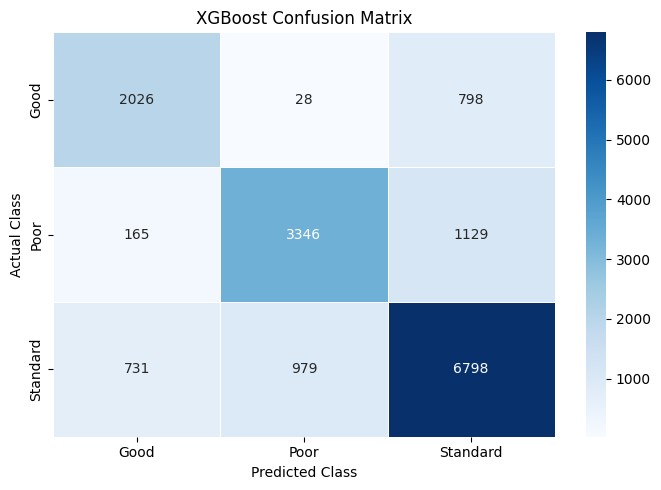

In [123]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.5
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [124]:
import joblib

joblib.dump(xgb_model, "XGBoost_model.joblib")

print("✅ XGBoost model saved successfully!")

✅ XGBoost model saved successfully!


In [127]:
joblib.dump(label_encoders, "label_encoders.joblib")

['label_encoders.joblib']